In [174]:
import pandas as pd
df = pd.read_csv('./backend/mumbai.csv')
df.head()
df.tail()

,time,temperature_2m_max (°C),temperature_2m_min (°C),rain_sum (mm),precipitation_sum (mm),precipitation_hours (h),sunshine_duration (s),wind_speed_10m_max (km/h),weather_code (wmo code),wind_direction_10m_dominant (°),relative_humidity_2m_mean (%)
1237,2026-05-22,33.5,29.5,1.9,1.9,9.0,41316.70,12.0,51,224,70
1238,2026-05-23,33.5,29.6,1.9,1.9,10.0,40172.75,12.8,53,250,69
1239,2026-05-24,34.0,29.4,2.6,2.6,13.0,42365.05,15.3,51,269,70
1240,2026-05-25,33.8,28.8,2.3,2.3,14.0,43200.00,16.3,51,282,71
1241,2026-05-26,33.8,29.0,0.7,0.7,4.0,43200.00,13.1,51,264,67


In [175]:
df.columns

Index(['time', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'rain_sum (mm)', 'precipitation_sum (mm)', 'precipitation_hours (h)',
       'sunshine_duration (s)', 'wind_speed_10m_max (km/h)',
       'weather_code (wmo code)', 'wind_direction_10m_dominant (°)',
       'relative_humidity_2m_mean (%)'],
      dtype='object')

In [176]:
df.isnull().sum()

time                               0
temperature_2m_max (°C)            0
temperature_2m_min (°C)            0
rain_sum (mm)                      0
precipitation_sum (mm)             0
precipitation_hours (h)            0
sunshine_duration (s)              0
wind_speed_10m_max (km/h)          0
weather_code (wmo code)            0
wind_direction_10m_dominant (°)    0
relative_humidity_2m_mean (%)      0
dtype: int64

In [177]:
df.shape

(1242, 11)

In [178]:
# targets for next day prediction

df["target_max_temp"] = df["temperature_2m_max (°C)"].shift(-1)

df["target_min_temp"] = df["temperature_2m_min (°C)"].shift(-1)

df["target_weather_code"] = df["weather_code (wmo code)"].shift(-1)

# remove last row (because target becomes NaN)
df = df.dropna()

print(df[[
    "temperature_2m_max (°C)",
    "target_max_temp",
    "temperature_2m_min (°C)",
    "target_min_temp",
    "weather_code (wmo code)",
    "target_weather_code"
]].head())

   temperature_2m_max (°C)  target_max_temp  temperature_2m_min (°C)  \
0                     27.3             29.1                     16.4   
1                     29.1             29.1                     16.5   
2                     29.1             28.6                     17.0   
3                     28.6             29.8                     17.1   
4                     29.8             31.6                     19.4   

   target_min_temp  weather_code (wmo code)  target_weather_code  
0             16.5                        3                  0.0  
1             17.0                        0                  3.0  
2             17.1                        3                  2.0  
3             19.4                        2                  2.0  
4             20.9                        2                  1.0  


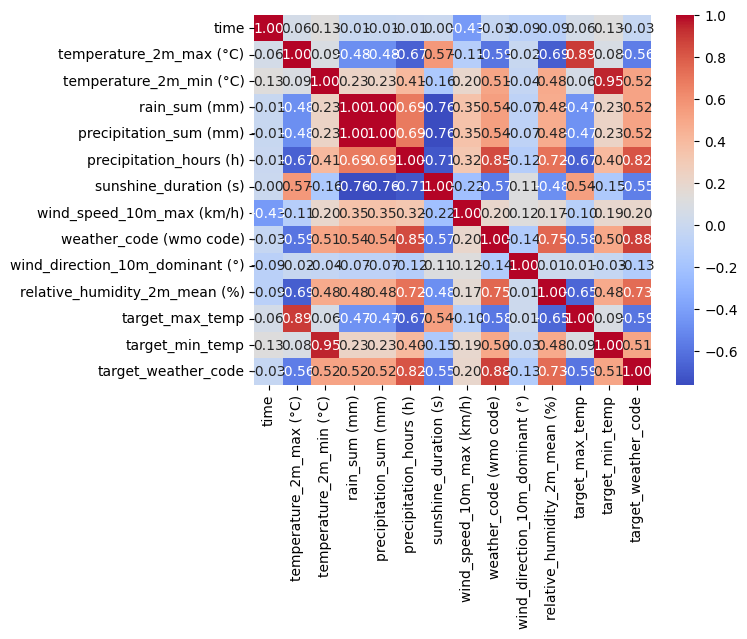

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt

df["time"] = pd.to_datetime(df["time"])
# Calculate correlation matrix
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()


In [180]:

df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["day_of_week"] = df["time"].dt.dayofweek
df["day_of_year"] = df["time"].dt.dayofyear


features = [

    "temperature_2m_max (°C)",
    "temperature_2m_min (°C)",
    "rain_sum (mm)",
    "month",
    "day",
    "day_of_week",
    "day_of_year",
    "precipitation_sum (mm)",
    "precipitation_hours (h)",
    "sunshine_duration (s)",
    "relative_humidity_2m_mean (%)",
    "wind_speed_10m_max (km/h)",
    "wind_direction_10m_dominant (°)",
    "weather_code (wmo code)"

]

X = df[features]

y_max = df["target_max_temp"]

y_min = df["target_min_temp"]

y_weather = df["target_weather_code"]

print(X.head())

print(y_max.head())

   temperature_2m_max (°C)  temperature_2m_min (°C)  rain_sum (mm)  month  \
0                     27.3                     16.4            0.0      1   
1                     29.1                     16.5            0.0      1   
2                     29.1                     17.0            0.0      1   
3                     28.6                     17.1            0.0      1   
4                     29.8                     19.4            0.0      1   

   day  day_of_week  day_of_year  precipitation_sum (mm)  \
0    1            6            1                     0.0   
1    2            0            2                     0.0   
2    3            1            3                     0.0   
3    4            2            4                     0.0   
4    5            3            5                     0.0   

   precipitation_hours (h)  sunshine_duration (s)  \
0                      0.0               37277.32   
1                      0.0               37257.76   
2                

In [181]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_max_train = y_max.iloc[:split_index]
y_max_test = y_max.iloc[split_index:]

y_min_train = y_min.iloc[:split_index]
y_min_test = y_min.iloc[split_index:]

y_weather_train = y_weather.iloc[:split_index]
y_weather_test = y_weather.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(992, 14)
(249, 14)


In [182]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# create model
max_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

# train
max_model.fit(X_train, y_max_train)

# predict
max_predictions = max_model.predict(X_test)

# evaluate
mae = mean_absolute_error(y_max_test, max_predictions)

print("MAE:", mae)
# accuracy score
print("Accuracy:", max_model.score(X_test, y_max_test))

print("\nFirst 10 Predictions:\n")

for real, pred in zip(y_max_test[:10], max_predictions[:10]):
    print(f"Actual: {real:.1f} | Predicted: {pred:.1f}")

MAE: 0.938074966532798
Accuracy: 0.7222428907529574

First 10 Predictions:

Actual: 29.0 | Predicted: 28.1
Actual: 28.6 | Predicted: 28.3
Actual: 28.3 | Predicted: 28.4
Actual: 28.7 | Predicted: 28.3
Actual: 28.6 | Predicted: 28.8
Actual: 28.1 | Predicted: 28.0
Actual: 29.1 | Predicted: 28.3
Actual: 28.2 | Predicted: 28.8
Actual: 26.5 | Predicted: 28.3
Actual: 28.3 | Predicted: 27.4


In [183]:
# MIN TEMP MODEL

min_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

# train
min_model.fit(X_train, y_min_train)

# predict
min_predictions = min_model.predict(X_test)

# evaluate
min_mae = mean_absolute_error(y_min_test, min_predictions)

print("MIN TEMP MAE:", min_mae)

# accuracy score
print("MIN TEMP Accuracy:", min_model.score(X_test, y_min_test))

print("\nFirst 10 Predictions:\n")

for real, pred in zip(y_min_test[:10], min_predictions[:10]):
    print(f"Actual: {real:.1f} | Predicted: {pred:.1f}")
# accuracy


MIN TEMP MAE: 0.6354685408299838
MIN TEMP Accuracy: 0.9198797000733538

First 10 Predictions:

Actual: 24.7 | Predicted: 24.6
Actual: 24.0 | Predicted: 24.7
Actual: 24.1 | Predicted: 24.3
Actual: 24.5 | Predicted: 24.6
Actual: 24.5 | Predicted: 24.6
Actual: 24.2 | Predicted: 24.5
Actual: 24.2 | Predicted: 24.4
Actual: 24.5 | Predicted: 24.3
Actual: 25.2 | Predicted: 24.9
Actual: 24.1 | Predicted: 24.9


In [184]:
def simplify_weather(code):

    if code == 0:
        return "sunny"

    elif code in [1, 2, 3]:
        return "cloudy"

    elif code in [45, 48]:
        return "foggy"

    elif code in [51, 53, 55, 61, 63, 65]:
        return "rainy"

    elif code in [71, 73, 75]:
        return "snowy"

    elif code >= 95:
        return "stormy"

    else:
        return "other"


df["weather_label"] = df["weather_code (wmo code)"].apply(simplify_weather)

df["target_weather_label"] = df["target_weather_code"].apply(simplify_weather)

print(df[[
    "weather_code (wmo code)",
    "weather_label",
    "target_weather_code",
    "target_weather_label"
]].head(10))

   weather_code (wmo code) weather_label  target_weather_code  \
0                        3        cloudy                  0.0   
1                        0         sunny                  3.0   
2                        3        cloudy                  2.0   
3                        2        cloudy                  2.0   
4                        2        cloudy                  1.0   
5                        1        cloudy                  2.0   
6                        2        cloudy                  2.0   
7                        2        cloudy                  0.0   
8                        0         sunny                  0.0   
9                        0         sunny                  0.0   

  target_weather_label  
0                sunny  
1               cloudy  
2               cloudy  
3               cloudy  
4               cloudy  
5               cloudy  
6               cloudy  
7                sunny  
8                sunny  
9                sunny  


In [185]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# split weather labels

y_weather_label = df["target_weather_label"]

y_weather_train = y_weather_label.iloc[:split_index]
y_weather_test = y_weather_label.iloc[split_index:]

# create classifier

weather_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# train

weather_model.fit(X_train, y_weather_train)

# predict

weather_predictions = weather_model.predict(X_test)

# accuracy

accuracy = accuracy_score(
    y_weather_test,
    weather_predictions
)

print("Accuracy:", accuracy)

print("\nFirst 20 Predictions:\n")

for real, pred in zip(
    y_weather_test[:20],
    weather_predictions[:20]
):
    print(f"Actual: {real} | Predicted: {pred}")

Accuracy: 0.6465863453815262

First 20 Predictions:

Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: rainy | Predicted: rainy
Actual: cloudy | Predicted: rainy


In [186]:
df.columns

Index(['time', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'rain_sum (mm)', 'precipitation_sum (mm)', 'precipitation_hours (h)',
       'sunshine_duration (s)', 'wind_speed_10m_max (km/h)',
       'weather_code (wmo code)', 'wind_direction_10m_dominant (°)',
       'relative_humidity_2m_mean (%)', 'target_max_temp', 'target_min_temp',
       'target_weather_code', 'month', 'day', 'day_of_week', 'day_of_year',
       'weather_label', 'target_weather_label'],
      dtype='object')

In [187]:
df.dtypes

time                               datetime64[ns]
temperature_2m_max (°C)                   float64
temperature_2m_min (°C)                   float64
rain_sum (mm)                             float64
precipitation_sum (mm)                    float64
precipitation_hours (h)                   float64
sunshine_duration (s)                     float64
wind_speed_10m_max (km/h)                 float64
weather_code (wmo code)                     int64
wind_direction_10m_dominant (°)             int64
relative_humidity_2m_mean (%)               int64
target_max_temp                           float64
target_min_temp                           float64
target_weather_code                       float64
month                                       int32
day                                         int32
day_of_week                                 int32
day_of_year                                 int32
weather_label                              object
target_weather_label                       object


In [188]:
latest_data = X.iloc[-1]

print(latest_data)

temperature_2m_max (°C)               33.8
temperature_2m_min (°C)               28.8
rain_sum (mm)                          2.3
month                                  5.0
day                                   25.0
day_of_week                            0.0
day_of_year                          145.0
precipitation_sum (mm)                 2.3
precipitation_hours (h)               14.0
sunshine_duration (s)              43200.0
relative_humidity_2m_mean (%)         71.0
wind_speed_10m_max (km/h)             16.3
wind_direction_10m_dominant (°)      282.0
weather_code (wmo code)               51.0
Name: 1240, dtype: float64


In [189]:
future_predictions = []

current_input = latest_data.copy()

for day in range(7):

    # predict temperatures
    next_max = max_model.predict([current_input])[0]
    next_min = min_model.predict([current_input])[0]

    # predict weather
    next_weather = weather_model.predict([current_input])[0]
    weather_mapping = {
    "sunny": 0,
    "cloudy": 3,
    "rainy": 61,
    "foggy": 45,
    "snowy": 71,
    "stormy": 95,
    "other": 1
    }

    current_input["weather_code (wmo code)"] = (
        weather_mapping[next_weather]
    )

    # store prediction
    future_predictions.append({
        "day": day + 1,
        "predicted_max_temp": float(round(next_max, 1)),
        "predicted_min_temp": float(round(next_min, 1)),
        "predicted_weather": next_weather
    })

    # update inputs for next prediction
    current_input["temperature_2m_max (°C)"] = next_max
    current_input["temperature_2m_min (°C)"] = next_min

print("\n7-Day Forecast:\n")

for forecast in future_predictions:
    print(forecast)


7-Day Forecast:

{'day': 1, 'predicted_max_temp': 33.6, 'predicted_min_temp': 28.4, 'predicted_weather': 'rainy'}
{'day': 2, 'predicted_max_temp': 33.5, 'predicted_min_temp': 28.2, 'predicted_weather': 'rainy'}
{'day': 3, 'predicted_max_temp': 33.5, 'predicted_min_temp': 28.1, 'predicted_weather': 'rainy'}
{'day': 4, 'predicted_max_temp': 33.5, 'predicted_min_temp': 28.1, 'predicted_weather': 'rainy'}
{'day': 5, 'predicted_max_temp': 33.5, 'predicted_min_temp': 28.1, 'predicted_weather': 'rainy'}
{'day': 6, 'predicted_max_temp': 33.5, 'predicted_min_temp': 28.1, 'predicted_weather': 'rainy'}
{'day': 7, 'predicted_max_temp': 33.5, 'predicted_min_temp': 28.1, 'predicted_weather': 'rainy'}


/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomFo

In [190]:
future_predictions = []

current_input = latest_data.copy()

# start from the latest date in your dataframe
current_date = df["time"].iloc[-1]

weather_mapping = {
    "sunny": 0,
    "cloudy": 3,
    "rainy": 61,
    "foggy": 45,
    "snowy": 71,
    "stormy": 95,
    "other": 1
}

for day in range(7):

    # increment date
    current_date = current_date + pd.Timedelta(days=1)

    # update date-based features
    current_input["month"] = current_date.month
    current_input["day"] = current_date.day
    current_input["day_of_week"] = current_date.dayofweek
    current_input["day_of_year"] = current_date.dayofyear

    # predict temperatures
    next_max = max_model.predict([current_input])[0]
    next_min = min_model.predict([current_input])[0]

    # predict weather
    next_weather = weather_model.predict([current_input])[0]

    # update weather code feature
    current_input["weather_code (wmo code)"] = (
        weather_mapping.get(next_weather, 1)
    )

    # store prediction
    future_predictions.append({
        "date": current_date.strftime("%Y-%m-%d"),
        "predicted_max_temp": float(round(next_max, 1)),
        "predicted_min_temp": float(round(next_min, 1)),
        "predicted_weather": next_weather
    })

    # update temperature features for next iteration
    current_input["temperature_2m_max (°C)"] = next_max
    current_input["temperature_2m_min (°C)"] = next_min

print("\n7-Day Forecast:\n")

for forecast in future_predictions:
    print(forecast)

/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



7-Day Forecast:

{'date': '2026-05-26', 'predicted_max_temp': 33.6, 'predicted_min_temp': 28.5, 'predicted_weather': 'rainy'}
{'date': '2026-05-27', 'predicted_max_temp': 33.7, 'predicted_min_temp': 28.4, 'predicted_weather': 'rainy'}
{'date': '2026-05-28', 'predicted_max_temp': 33.7, 'predicted_min_temp': 28.3, 'predicted_weather': 'rainy'}
{'date': '2026-05-29', 'predicted_max_temp': 33.8, 'predicted_min_temp': 28.2, 'predicted_weather': 'rainy'}
{'date': '2026-05-30', 'predicted_max_temp': 33.8, 'predicted_min_temp': 28.1, 'predicted_weather': 'rainy'}
{'date': '2026-05-31', 'predicted_max_temp': 33.8, 'predicted_min_temp': 28.1, 'predicted_weather': 'rainy'}
{'date': '2026-06-01', 'predicted_max_temp': 33.8, 'predicted_min_temp': 28.1, 'predicted_weather': 'rainy'}


/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dsenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomFo

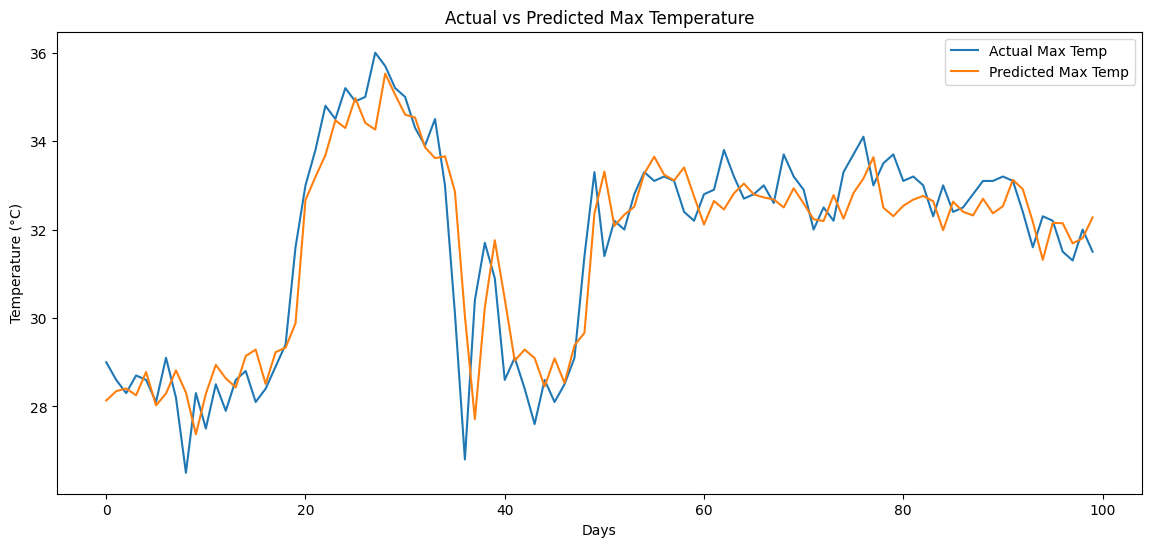

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_max_test.values[:100],
    label="Actual Max Temp"
)

plt.plot(
    max_predictions[:100],
    label="Predicted Max Temp"
)

plt.title("Actual vs Predicted Max Temperature")

plt.xlabel("Days")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()

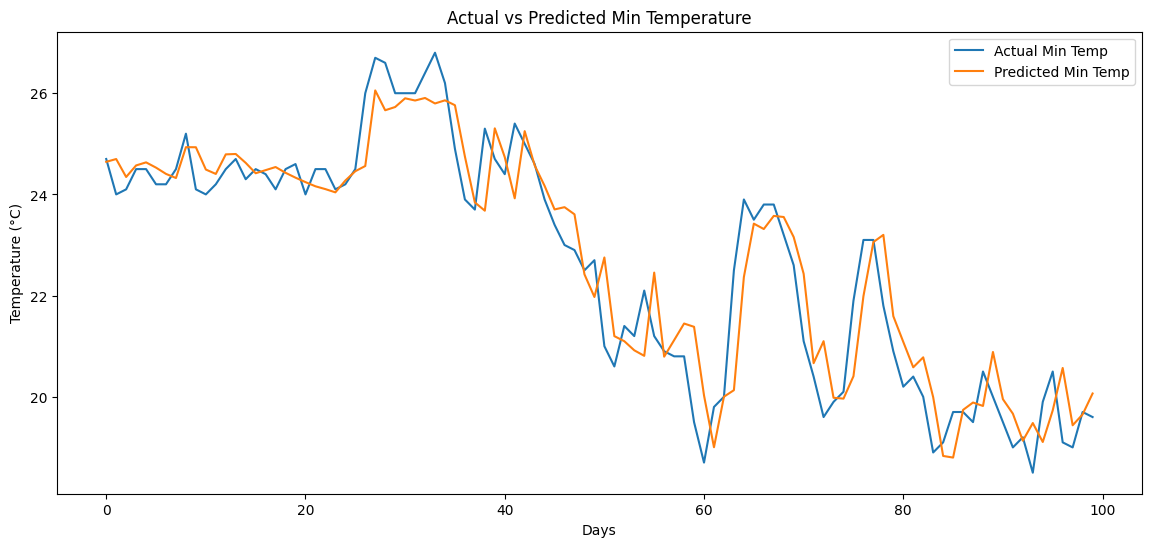

In [192]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_min_test.values[:100],
    label="Actual Min Temp"
)

plt.plot(
    min_predictions[:100],
    label="Predicted Min Temp"
)

plt.title("Actual vs Predicted Min Temperature")

plt.xlabel("Days")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.show()

In [193]:
future_days = [x["day"] for x in future_predictions]

future_max = [
    x["predicted_max_temp"]
    for x in future_predictions
]

future_min = [
    x["predicted_min_temp"]
    for x in future_predictions
]

plt.figure(figsize=(12,6))

plt.plot(
    future_days,
    future_max,
    marker="o",
    label="Predicted Max Temp"
)

plt.plot(
    future_days,
    future_min,
    marker="o",
    label="Predicted Min Temp"
)

plt.title("7-Day Weather Forecast")

plt.xlabel("Future Days")
plt.ylabel("Temperature (°C)")

plt.xticks(future_days)

plt.legend()

plt.show()

KeyError: 'day'

In [ ]:
# import joblib

# joblib.dump(max_model, "models/delhi/max.pkl")
# joblib.dump(min_model, "models/delhi/min.pkl")
# joblib.dump(weather_model, "models/delhi/weather.pkl")

In [ ]:
df.columns

Index(['time', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'rain_sum (mm)', 'precipitation_sum (mm)', 'precipitation_hours (h)',
       'sunshine_duration (s)', 'weather_code (wmo code)',
       'wind_direction_10m_dominant (°)', 'relative_humidity_2m_mean (%)',
       'wind_speed_10m_max (km/h)', 'target_max_temp', 'target_min_temp',
       'target_weather_code', 'month', 'day', 'day_of_week', 'day_of_year',
       'weather_label', 'target_weather_label'],
      dtype='object')

In [ ]:
df['target_weather_label'].value_counts()

target_weather_label
cloudy    588
rainy     550
sunny     101
Name: count, dtype: int64

In [ ]:
df[df['month'] == 4]

,time,temperature_2m_max (°C),temperature_2m_min (°C),rain_sum (mm),precipitation_sum (mm),precipitation_hours (h),sunshine_duration (s),weather_code (wmo code),wind_direction_10m_dominant (°),relative_humidity_2m_mean (%),wind_speed_10m_max (km/h),target_max_temp,target_min_temp,target_weather_code,month,day,day_of_week,day_of_year,weather_label,target_weather_label
90,2023-04-01,33.2,21.1,0.0,0.0,0.0,42947.86,3,359,52,14.8,33.4,20.8,51.0,4,1,5,91,cloudy,rainy
91,2023-04-02,33.4,20.8,0.5,0.5,2.0,35759.09,51,2,60,9.1,34.2,21.4,3.0,4,2,6,92,rainy,cloudy
92,2023-04-03,34.2,21.4,0.0,0.0,0.0,42970.47,3,169,54,12.3,35.1,22.4,3.0,4,3,0,93,cloudy,cloudy
93,2023-04-04,35.1,22.4,0.0,0.0,0.0,42982.04,3,208,52,16.3,34.3,21.4,3.0,4,4,1,94,cloudy,cloudy
94,2023-04-05,34.3,21.4,0.0,0.0,0.0,42990.11,3,175,52,9.0,33.7,22.5,55.0,4,5,2,95,cloudy,rainy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211,2026-04-26,37.7,27.9,0.0,0.0,0.0,41232.43,3,192,37,12.9,39.1,27.6,3.0,4,26,6,116,cloudy,cloudy
1212,2026-04-27,39.1,27.6,0.0,0.0,0.0,42738.28,3,225,35,11.8,39.3,27.3,3.0,4,27,0,117,cloudy,cloudy
1213,2026-04-28,39.3,27.3,0.0,0.0,0.0,40960.48,3,207,37,12.2,39.3,28.0,3.0,4,28,1,118,cloudy,cloudy
1214,2026-04-29,39.3,28.0,0.0,0.0,0.0,39575.41,3,243,33,10.4,38.8,29.0,0.0,4,29,2,119,cloudy,sunny
